In [47]:
import pandas as pd
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf

import seaborn as sns
from sklearn.metrics import confusion_matrix

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout
from tensorflow.keras import regularizers

import numpy as np
from numpy.random import seed, randint

In [5]:
df = pd.read_parquet('plant_pictures.parquet')
df.image[0]

{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x06\x07\x06\x05\x08\x07\x07\x07\t\t\x08\n\x0c\x14\r\x0c\x0b\x0b\x0c\x19\x12\x13\x0f\x14\x1d\x1a\x1f\x1e\x1d\x1a\x1c\x1c $.\' ",#\x1c\x1c(7),01444\x1f\'9=82<.342\xff\xdb\x00C\x01\x08\t\t\x0c\x0b\x0c\x18\r\r\x182!\x1c!22222222222222222222222222222222222222222222222222\xff\xc0\x00\x11\x08\x00x\x00x\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1f\x00\x00\x01\x05\x01\x01\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b\xff\xc4\x00\xb5\x10\x00\x02\x01\x03\x03\x02\x04\x03\x05\x05\x04\x04\x00\x00\x01}\x01\x02\x03\x00\x04\x11\x05\x12!1A\x06\x13Qa\x07"q\x142\x81\x91\xa1\x08#B\xb1\xc1\x15R\xd1\xf0$3br\x82\t\n\x16\x17\x18\x19\x1a%&\'()*456789:CDEFGHIJSTUVWXYZcdefghijstuvwxyz\x83\x84\x85\x86\x87\x88\x89\x8a\x92\x93\x94\x95\x96\x97\x98\x99\x9a\xa2\xa3\xa4\xa5\xa6\xa7\xa8\xa9\xaa\xb2\xb3\xb4\xb5\xb6\xb7\xb8\xb9\xba\xc2\xc3\xc4\xc5\xc6\xc7\xc8\xc9\xca\xd

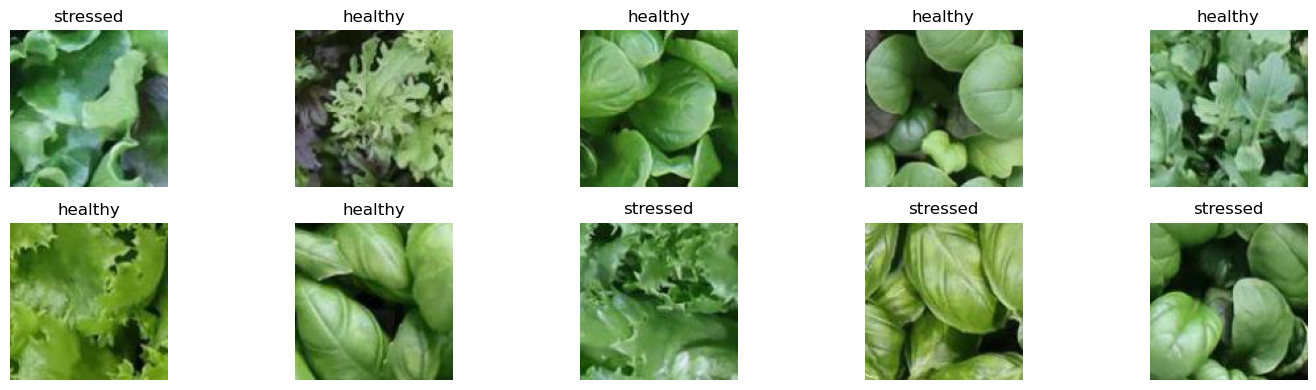

In [11]:
random_indices = np.random.choice(len(df), 10, replace=False)
plt.figure(figsize=(15, 4))
for i, idx in enumerate(random_indices):
    img = Image.open(BytesIO(df.image[idx]['bytes'])).convert("RGB")
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(df.label[idx])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6127 entries, 0 to 6126
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   image      6127 non-null   object
 1   mask       6127 non-null   object
 2   crop_type  6127 non-null   object
 3   label      6127 non-null   object
dtypes: object(4)
memory usage: 191.6+ KB


In [9]:
df.describe()

,image,mask,crop_type,label
count,6127,6127,6127,6127
unique,6127,1889,14,2
top,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,zx1,healthy
freq,1,4238,958,3798


In [10]:
df['label'].value_counts()

label
healthy     3798
stressed    2329
Name: count, dtype: int64

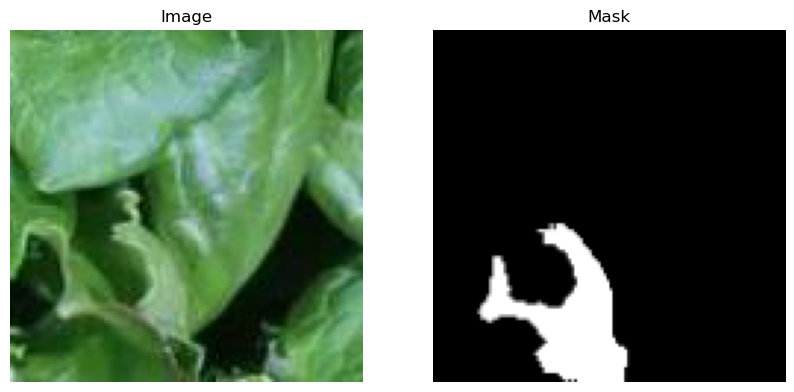

In [14]:
index = np.random.choice(len(df), 1, replace=False)[0]
row = df.iloc[index]
image = Image.open(BytesIO(row['image']['bytes']))
mask = Image.open(BytesIO(row['mask']['bytes']))

plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title('Mask')
plt.axis('off')
plt.show()

In [57]:
IMG_SIZE = 128

def decode_image(image_dict):
    img = Image.open(BytesIO(image_dict["bytes"])).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img)
    return arr

X = np.stack([decode_image(img) for img in df["image"]])

print(X.shape)

(6127, 128, 128, 3)


In [58]:
X = X.astype("float32") / 255.0

In [60]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["label"])

print(label_encoder.classes_)
print(y[:10])

['healthy' 'stressed']
[0 1 1 1 1 0 0 1 0 0]


In [61]:
num_classes = df['label'].nunique()

index = np.random.choice(len(df), 1, replace=False)[0]
print("i: ", index)
print("X[i]: ", X[int(index)])
print("y[i]: ", y[int(index)])

i:  187
X[i]:  [[[0.3882353  0.30588236 0.29411766]
  [0.38431373 0.3019608  0.2901961 ]
  [0.37254903 0.29803923 0.27450982]
  ...
  [0.08235294 0.11372549 0.01960784]
  [0.09803922 0.12941177 0.03529412]
  [0.10196079 0.13333334 0.03921569]]

 [[0.3882353  0.30588236 0.29411766]
  [0.37254903 0.2901961  0.2784314 ]
  [0.3529412  0.2784314  0.25882354]
  ...
  [0.08627451 0.11764706 0.02352941]
  [0.09411765 0.1254902  0.03137255]
  [0.09019608 0.12156863 0.02745098]]

 [[0.38431373 0.3019608  0.2901961 ]
  [0.36862746 0.28235295 0.26666668]
  [0.34901962 0.27058825 0.24705882]
  ...
  [0.09411765 0.1254902  0.03137255]
  [0.09019608 0.12156863 0.02745098]
  [0.07843138 0.10980392 0.01568628]]

 ...

 [[0.64705884 0.6784314  0.53333336]
  [0.6        0.6313726  0.4862745 ]
  [0.5647059  0.6039216  0.45882353]
  ...
  [0.3254902  0.37254903 0.23529412]
  [0.19215687 0.24705882 0.10588235]
  [0.09411765 0.14901961 0.00784314]]

 [[0.6156863  0.64705884 0.5019608 ]
  [0.5764706  0.607843

In [62]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify = y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, stratify=y_train_val)

In [82]:
# seeds control the reproductability of randomness
tf.random.set_seed(0) # tensorflow
input_size = IMG_SIZE * IMG_SIZE * 3

model = Sequential() # initialize a neural network
model.add(Input(shape=(input_size,))) # input layer
model.add(Dense(128, activation='tanh')) # hidden layer with 128 neurons and ReLU activation
model.add(Dense(units = num_classes, activation='softmax')) # output layer
sgd = SGD(learning_rate=0.01) # stochastic gradient descent
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)

history = model.fit(X_train_flat, y_train_cat, epochs=15, batch_size=32, verbose=1, validation_data=(X_val_flat, y_val_cat))

Epoch 1/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.4857 - loss: 3.5506 - val_accuracy: 0.6198 - val_loss: 0.6686
Epoch 2/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.6199 - loss: 0.6654 - val_accuracy: 0.6198 - val_loss: 0.6644
Epoch 3/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - accuracy: 0.6199 - loss: 0.6657 - val_accuracy: 0.6198 - val_loss: 0.6642
Epoch 4/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 17s 136ms/step - accuracy: 0.6199 - loss: 0.6660 - val_accuracy: 0.6198 - val_loss: 0.6642
Epoch 5/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 16s 127ms/step - accuracy: 0.6199 - loss: 0.6664 - val_accuracy: 0.6198 - val_loss: 0.6644
Epoch 6/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - accuracy: 0.6199 - loss: 0.6667 - val_accuracy: 0.6198 - val_loss: 0.6648
Epoch 7/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - accuracy: 0.6199 - loss: 0.6671 - val_accuracy: 0.6198 - val_loss: 0.6653
Epoch 8/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.6199 - loss: 0.

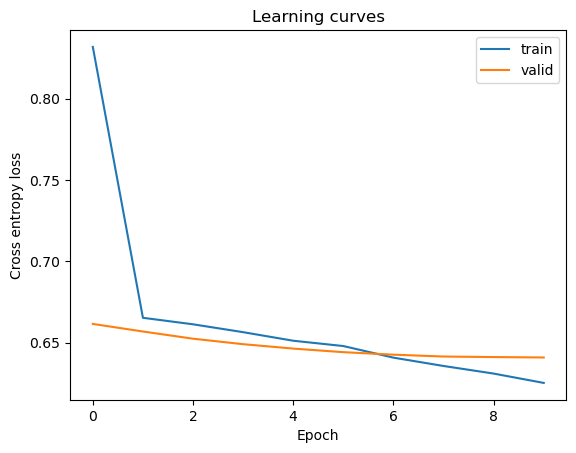

In [67]:
plt.figure()
plt.title("Learning curves")
plt.xlabel("Epoch")
plt.ylabel("Cross entropy loss")
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'valid')
plt.legend()
plt.show()

In [71]:
# Use verbose=0 to hide the progress bars
train_results = model.evaluate(X_train_flat, y_train_cat, verbose=0)
val_results = model.evaluate(X_val_flat, y_val_cat, verbose=0)

print(f"Loss + accuracy on train data: {train_results}")
print(f"Loss + accuracy on validation data: {val_results}")

Loss + accuracy on train data: [0.5993459820747375, 0.6931122541427612]
Loss + accuracy on validation data: [0.6408956050872803, 0.6615698337554932]


In [74]:
probabilities = np.array(model.predict(X_val_flat))
predictions = np.argmax(probabilities, axis = 1) # what the model predicts
labels = np.argmax(y_val_cat, axis = 1) # what the actual labels are

print("Predictions = {}".format(predictions[0:30]))
print("Labels      = {}".format(labels[0:30]))

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Predictions = [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
Labels      = [1 0 1 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 1 0 1 0 0 1]


In [75]:
misclas_idxs = np.argwhere(predictions != labels)

print(f"Total misclassifications in val set: {len(misclas_idxs)}")
print(f"Size of the validation set: {len(X_val)}")

Total misclassifications in val set: 332
Size of the validation set: 981


C:\Users\youss\AppData\Local\Temp\ipykernel_19028\1591767522.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  idx = int(idx)


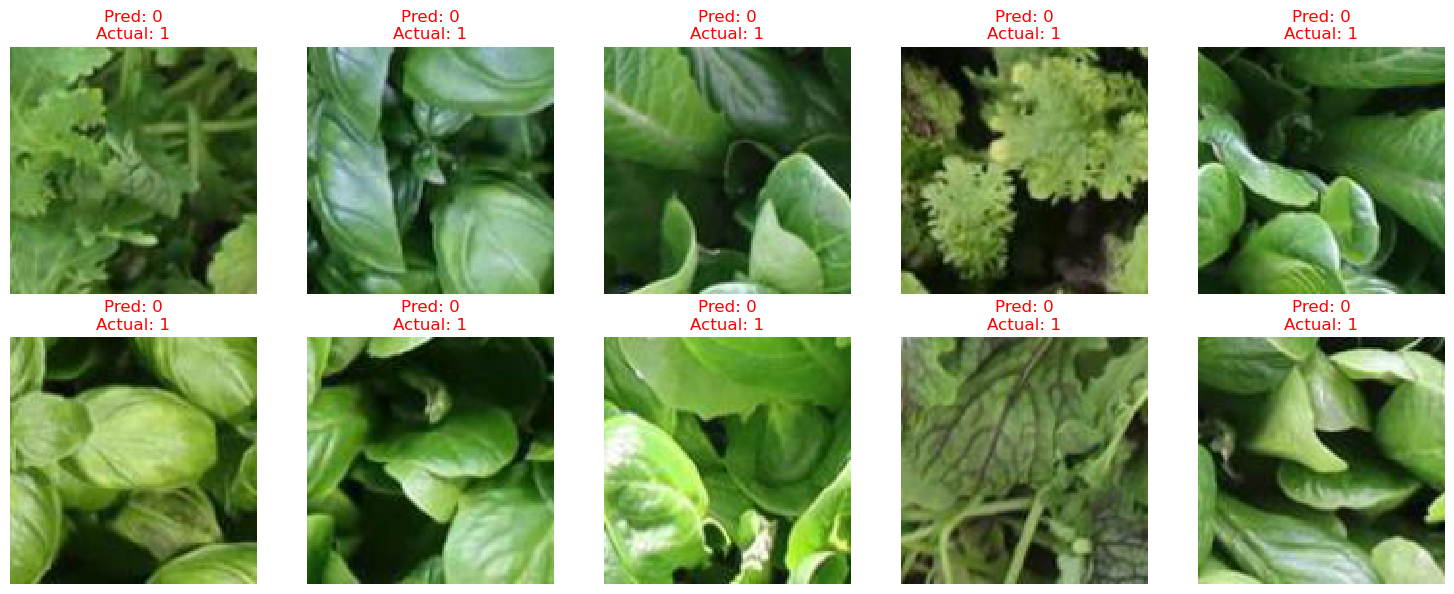

In [79]:
plt.figure(figsize=(15, 6))

for i, idx in enumerate(misclas_idxs[:10]):
    plt.subplot(2, 5, i + 1)
    idx = int(idx)
    img = X_val[idx]
    plt.imshow(img, interpolation='nearest')
    plt.title(f"Pred: {predictions[idx]}\nActual: {labels[idx]}", color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [81]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

# Re-build the model with Dropout and a different optimizer
model_v2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Added dropout
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Added dropout
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),   # Added dropout
    Dense(num_classes, activation='softmax')
])

# Compile the model with the Adam optimizer
model_v2.compile(optimizer=Adam(learning_rate=0.001),  # Using Adam optimizer
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_v2.summary()

# Train the new model
history_v2 = model_v2.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val_cat),
    verbose=1
)

c:\Users\youss\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,986 (14.14 MB)

 Trainable params: 3,705,986 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 40s 302ms/step - accuracy: 0.6043 - loss: 0.7814 - val_accuracy: 0.6198 - val_loss: 0.6586
Epoch 2/20
 88/123 ━━━━━━━━━━━━━━━━━━━━ 9s 272ms/step - accuracy: 0.6214 - loss: 0.6611

KeyboardInterrupt: 